In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import librosa

from birdclef_2026_ml.processing.memmap_dataset import load_memmap_dataset
from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import FeatureConfig
from birdclef_2026_ml.feature_engineering.feature_extract import *

feat_cfg = FeatureConfig()
paths = load_project_paths()
init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## GLCM

In [12]:
train_df = pd.read_parquet(paths.train_processed) 
soundscapes = pd.read_parquet(paths.soundscapes_processed)

#### Local

In [70]:
def plot_glcm_spectogram(row):
    y, _ = librosa.load(paths.train_audio_clean_dir / row["filename"], sr=feat_cfg.sr)
    mel_db = compute_mel_spectrogram(y, feat_cfg)
    glcm = extract_glcm_features(mel_db, feat_cfg)

    times = librosa.frames_to_time(
        np.arange(mel_db.shape[1]),
        sr=feat_cfg.sr,
        hop_length=feat_cfg.hop_length
    )

    title = f"{row["class_name"]} - {row["common_name"]} ({row["primary_label"]})"
    fig, axes = plt.subplots(
        5,
        1,
        figsize=(14, 12),
        sharex=False
    )
    fig.suptitle(title)

    # --- Spectrogram ---
    librosa.display.specshow(
        mel_db,
        sr=feat_cfg.sr,
        x_axis="time",
        y_axis="mel",
        ax=axes[0]
    )
    axes[0].set_title("Mel Spectrogram")

    # --- Time-direction GLCM features ---
    axes[1].plot(times, glcm["glcm_time_contrast"][0], label="contrast")
    axes[1].plot(times, glcm["glcm_time_entropy"][0], label="entropy")
    axes[1].set_title("GLCM Time Features")
    axes[1].legend(loc="upper left")

    axes[2].plot(times, glcm["glcm_time_homogeneity"][0], label="homogeneity")
    axes[2].plot(times, glcm["glcm_time_energy"][0], label="energy")
    axes[2].set_title("GLCM Time Structure")
    axes[2].legend(loc="upper left")

    # --- Frequency-direction GLCM features ---
    axes[3].plot(times, glcm["glcm_freq_contrast"][0], label="contrast")
    axes[3].plot(times, glcm["glcm_freq_entropy"][0], label="entropy")
    axes[3].set_title("GLCM Frequency Features")
    axes[3].legend(loc="upper left")

    axes[4].plot(times, glcm["glcm_freq_homogeneity"][0], label="homogeneity")
    axes[4].plot(times, glcm["glcm_freq_energy"][0], label="energy")
    axes[4].set_title("GLCM Frequency Structure")
    axes[4].legend(loc="upper left")

    plt.tight_layout()
    return fig

def plot_glcm_heatmap(row):
    y, _ = librosa.load(paths.train_audio_clean_dir / row["filename"], sr=feat_cfg.sr)
    mel_db = compute_mel_spectrogram(y, feat_cfg)
    glcm = extract_glcm_features(mel_db, feat_cfg)

    features = np.vstack([glcm[k] for k in glcm])

    fig = plt.figure(figsize=(14, 5))

    plt.imshow(
        features,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    plt.yticks(
        range(8),
        [
            "t_contrast", "t_entropy", "t_homogeneity", "t_energy",
            "f_contrast", "f_entropy", "f_homogeneity", "f_energy"
        ]
    )

    plt.title("GLCM Feature Map (Time × Feature)")
    plt.xlabel("Time frames")
    plt.colorbar()
    plt.grid(visible=False)
    return fig

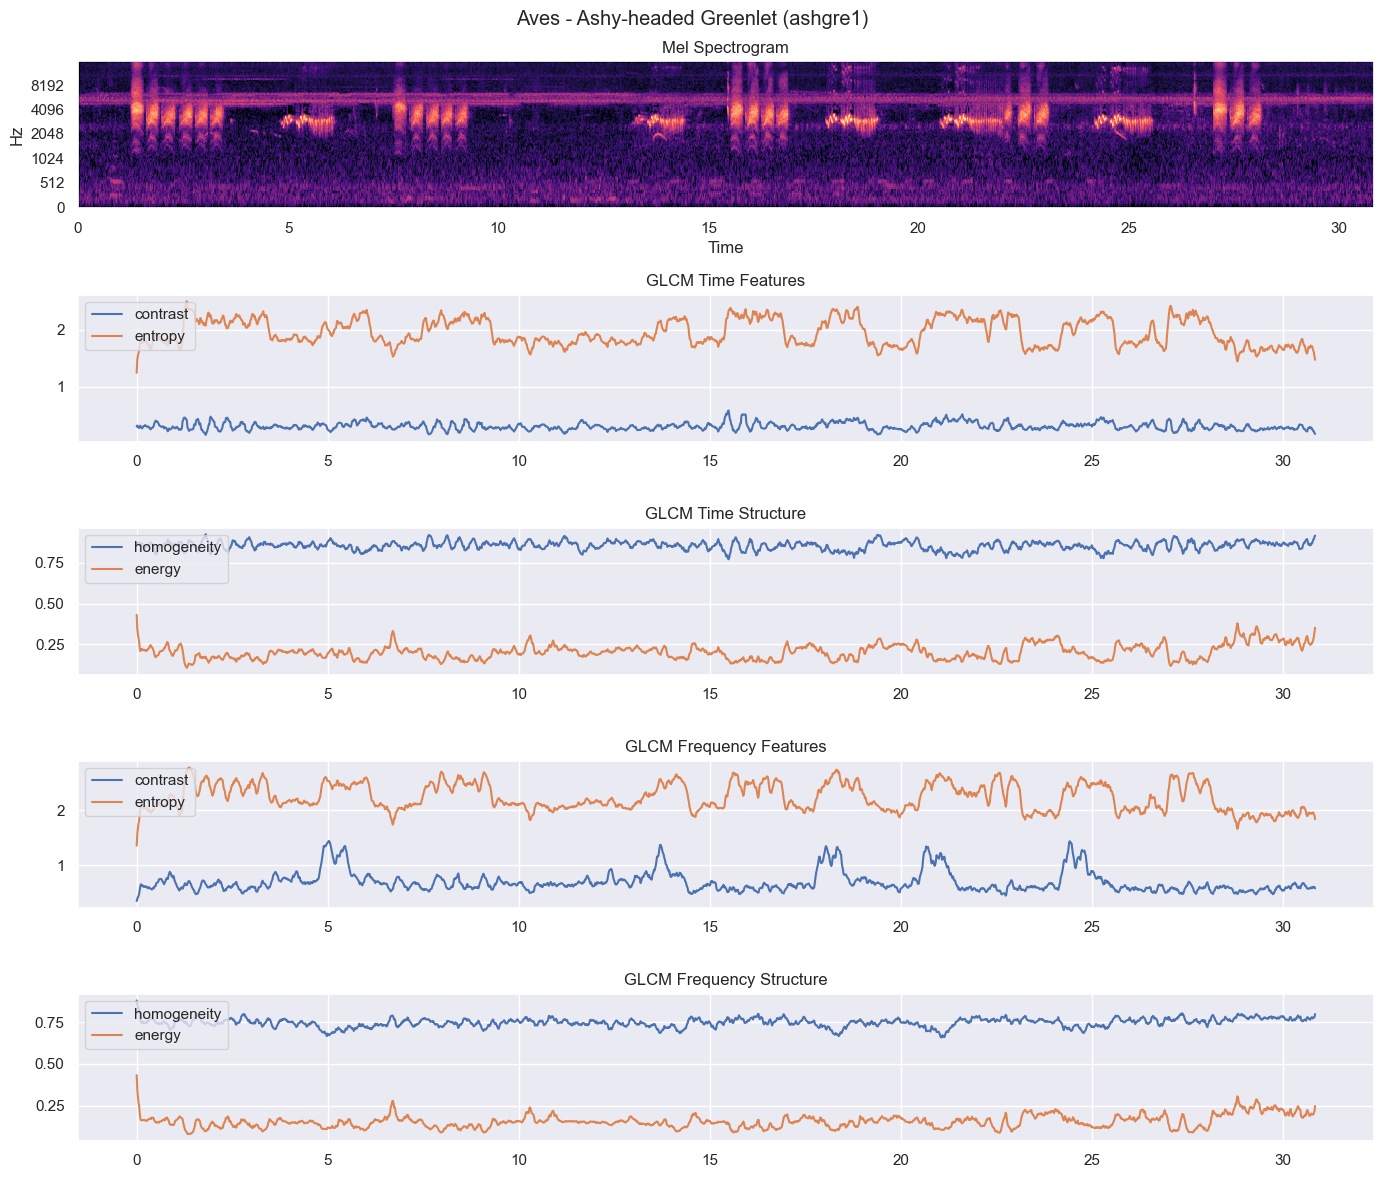

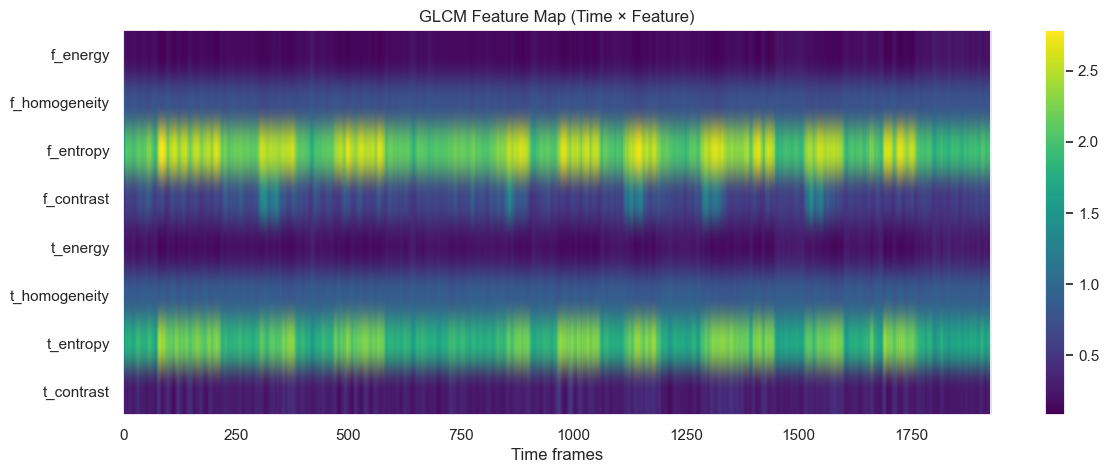

In [71]:
row = train_df[train_df["class_name"] == "Aves"].iloc[0]
fig1 = plot_glcm_spectogram(row)
fig2 = plot_glcm_heatmap(row)

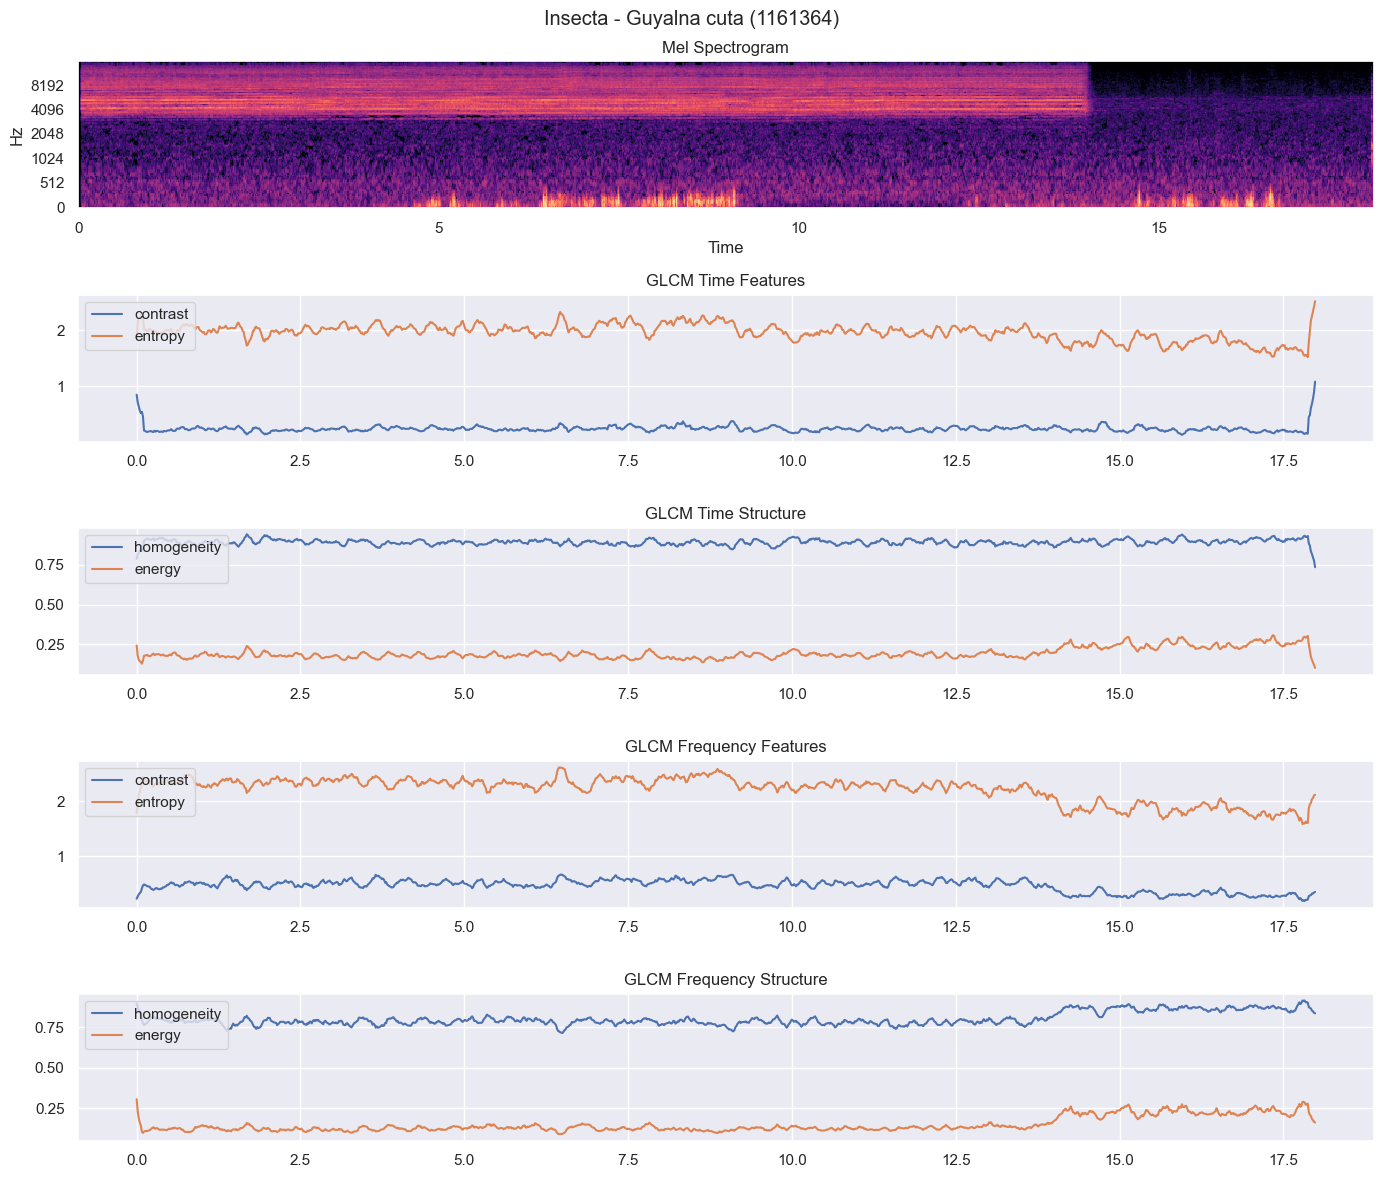

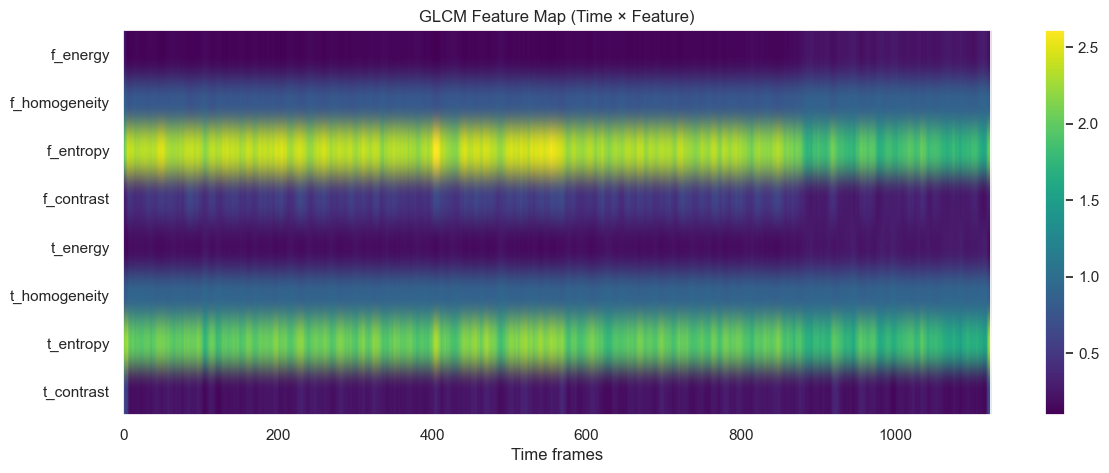

In [72]:
row = train_df[train_df["class_name"] == "Insecta"].iloc[0]
fig1 = plot_glcm_spectogram(row)
fig2 = plot_glcm_heatmap(row)

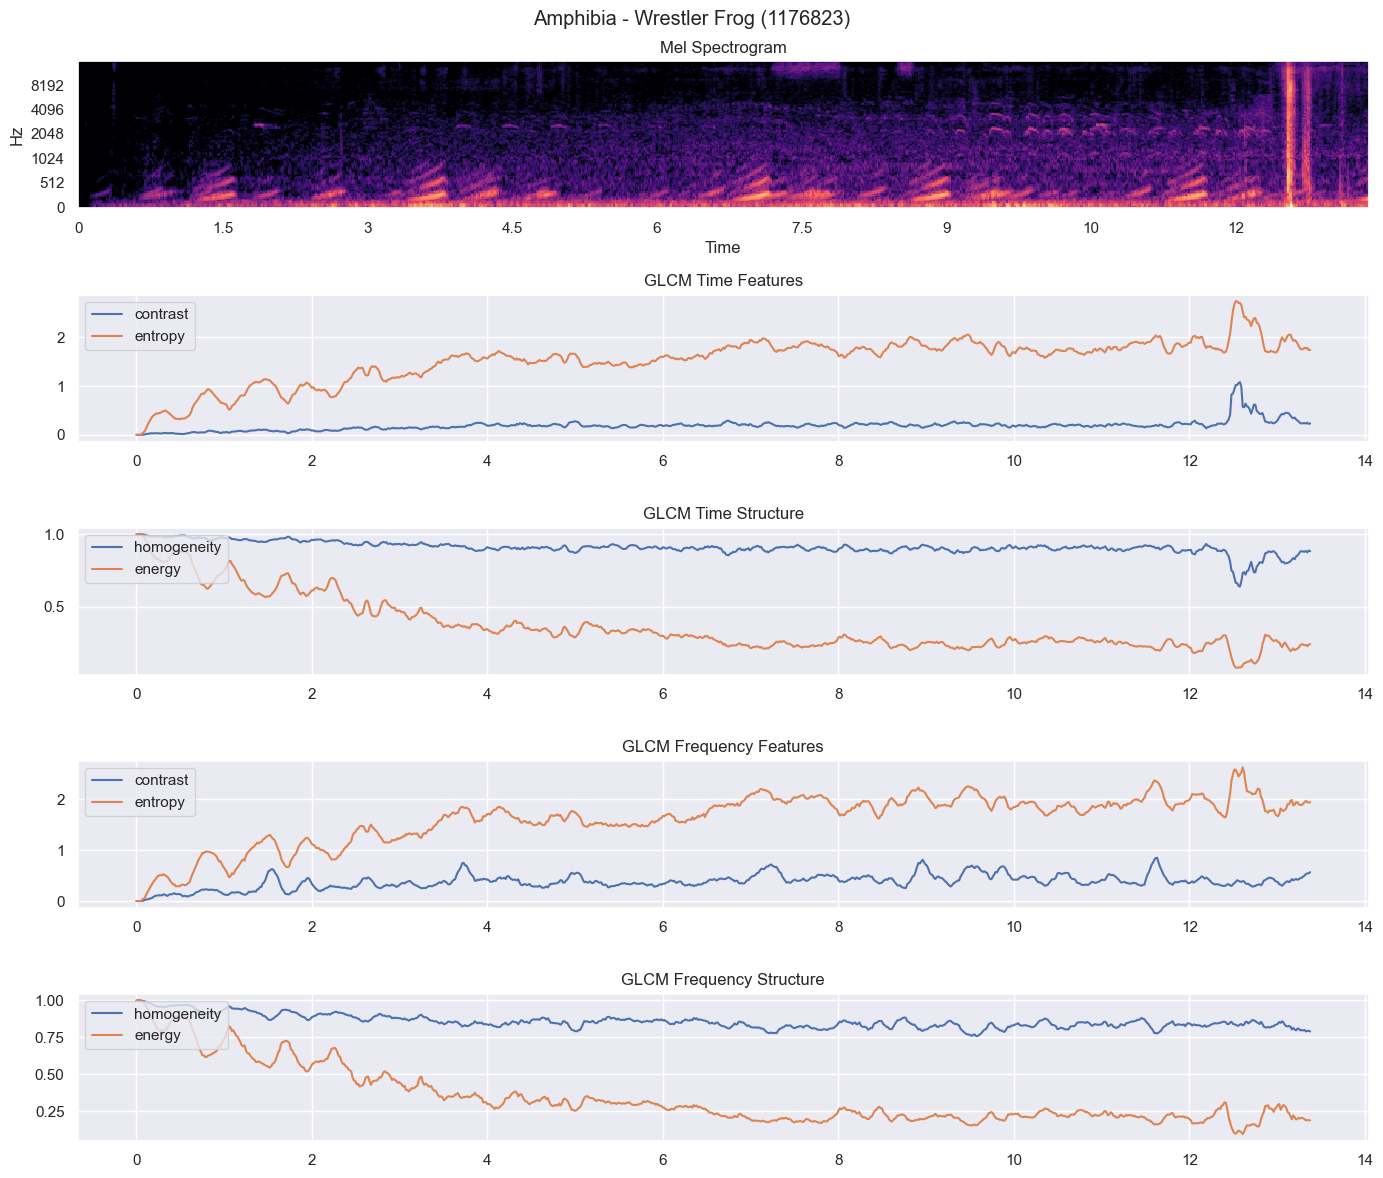

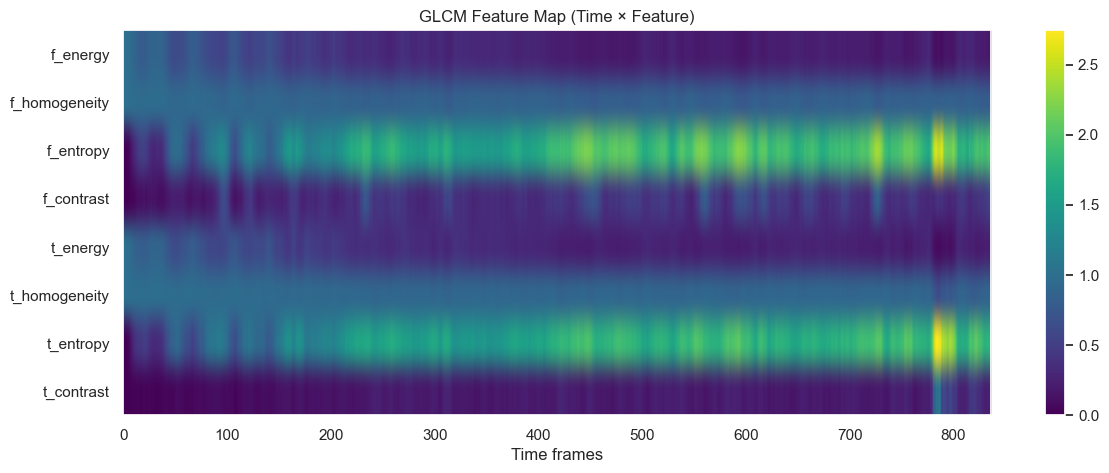

In [77]:
row = train_df[train_df["class_name"] == "Amphibia"].iloc[0]
fig1 = plot_glcm_spectogram(row)
fig2 = plot_glcm_heatmap(row)

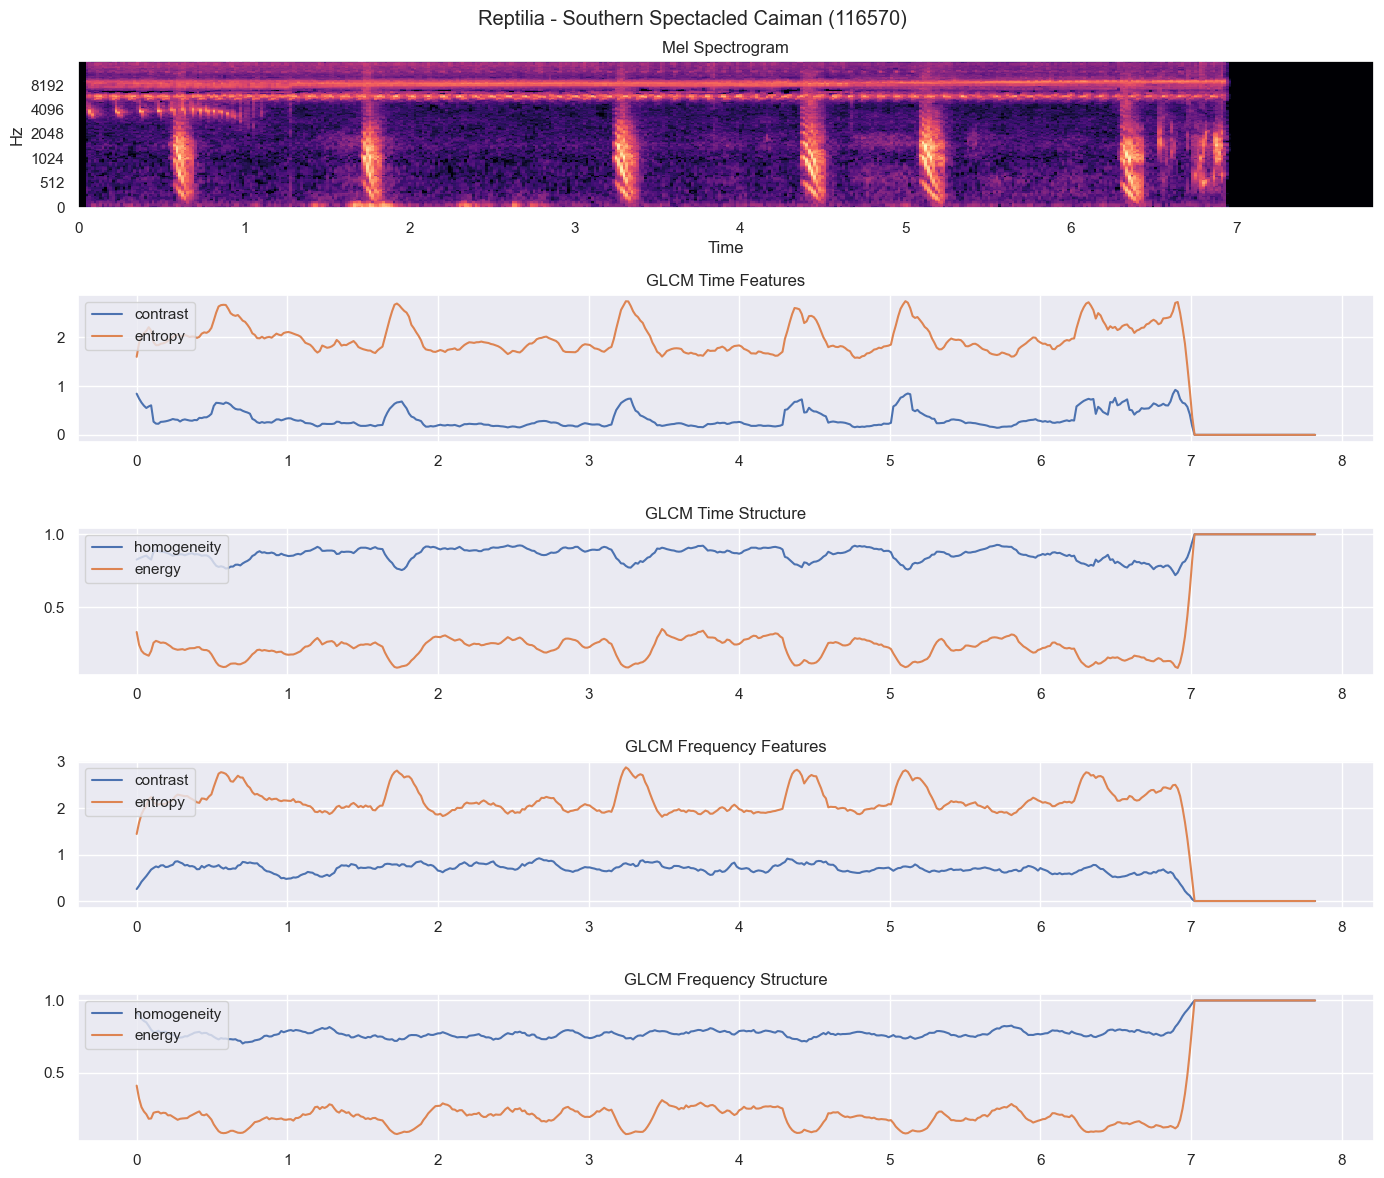

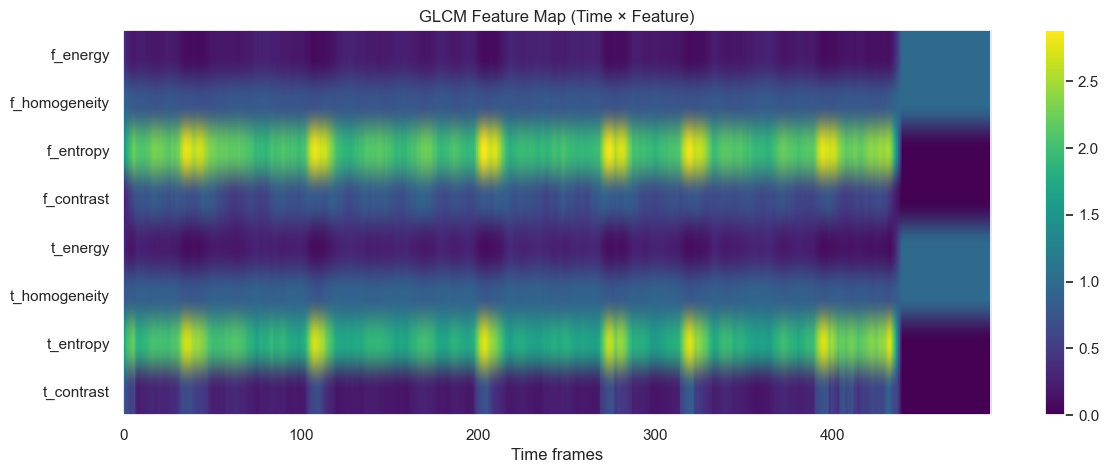

In [74]:
row = train_df[train_df["class_name"] == "Reptilia"].iloc[0]
fig1 = plot_glcm_spectogram(row)
fig2 = plot_glcm_heatmap(row)

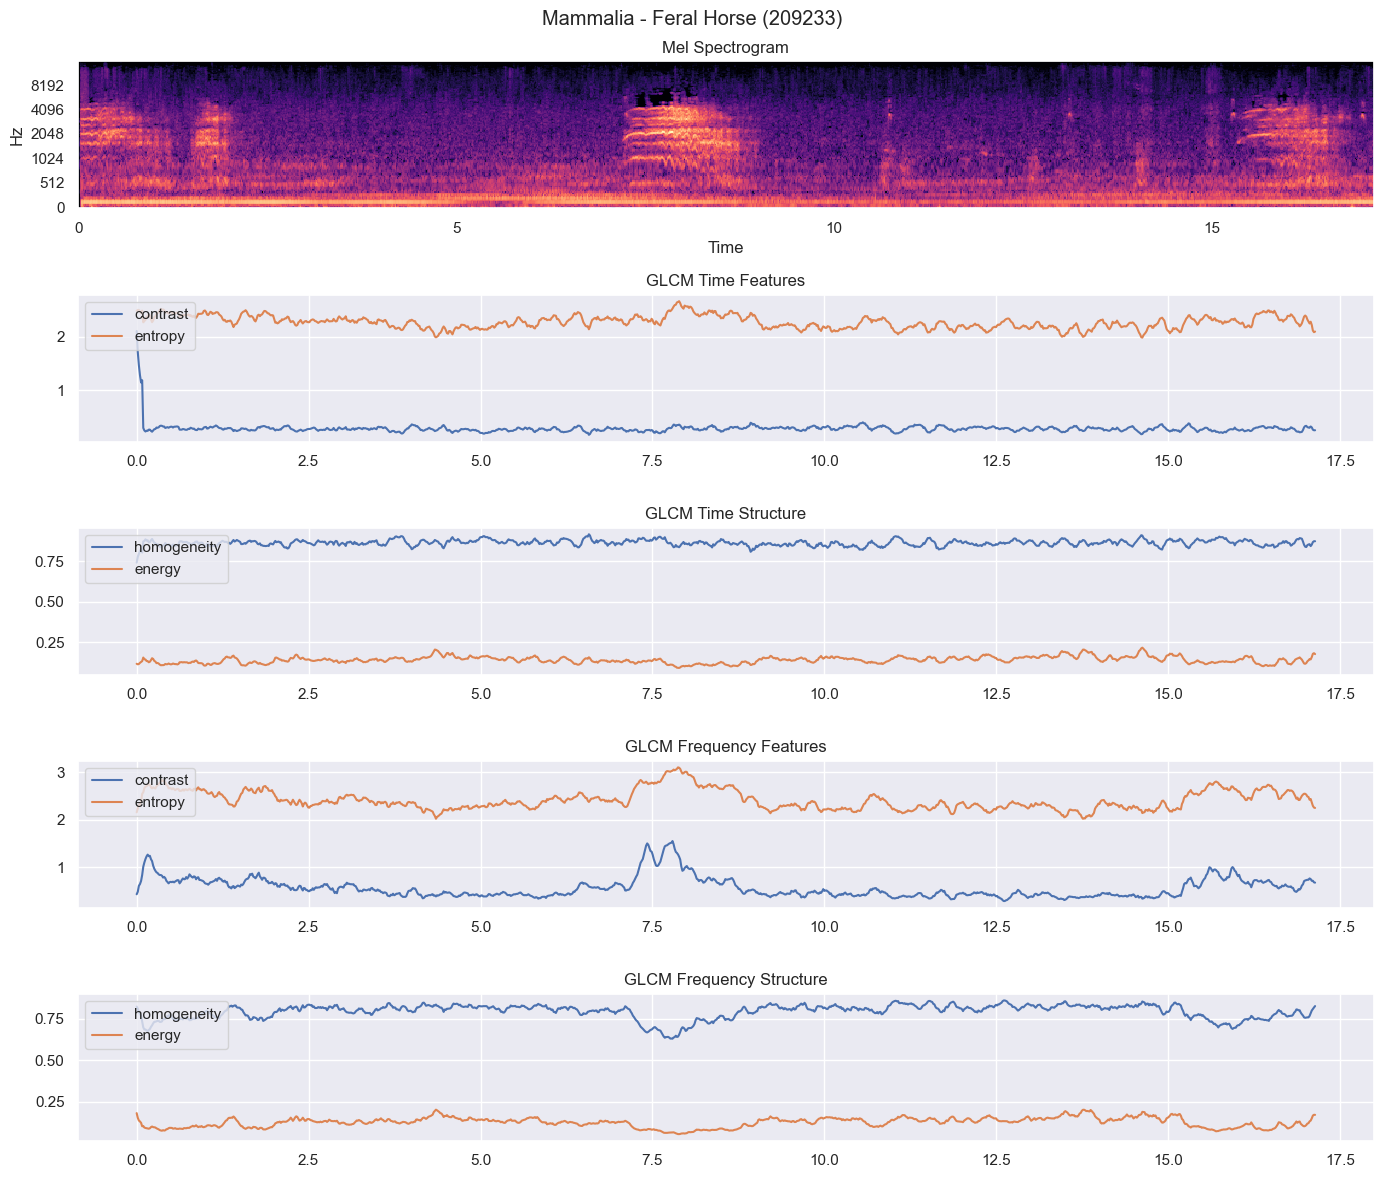

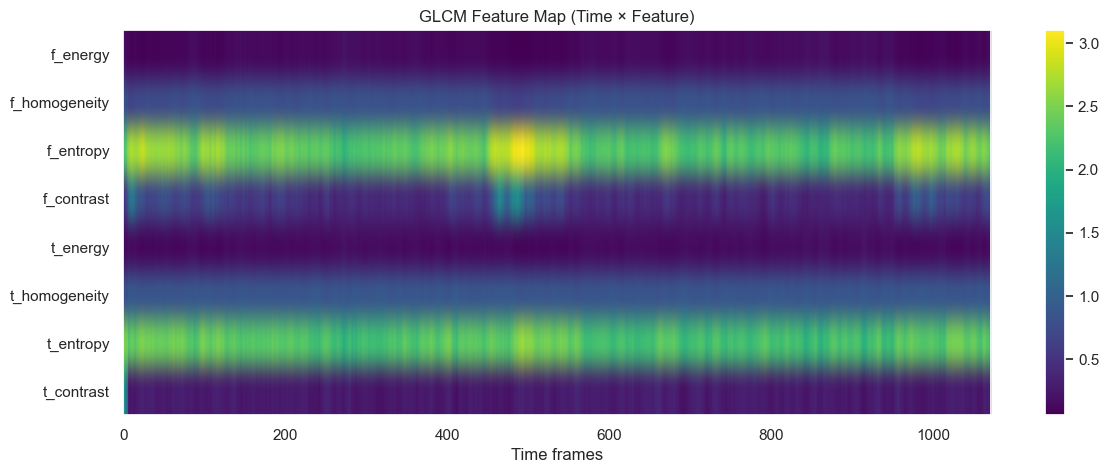

In [75]:
row = train_df[train_df["class_name"] == "Mammalia"].iloc[0]
fig1 = plot_glcm_spectogram(row)
fig2 = plot_glcm_heatmap(row)

## LBP

#### Local

In [130]:
def plot_lbp_heatmap(row):
    y, _ = librosa.load(paths.train_audio_clean_dir / row["filename"], sr=feat_cfg.sr)
    mel_db = compute_mel_spectrogram(y, feat_cfg)

    lbp_hist = extract_lbp_features(mel_db, feat_cfg)["lbp_hist"]

    fig, ax = plt.subplots(figsize=(14, 5))

    im = ax.imshow(
        lbp_hist,
        aspect="auto",
        origin="lower",
        cmap="viridis"
    )

    ax2 = ax.twinx()

    # Entropy-based complexity. High -> complex patterns, Low -> simple patterns
    complexity = -np.sum(lbp_hist * np.log(lbp_hist + 1e-10), 
                                      axis=0)
    ax2.plot(complexity, color="white", linewidth=1, label="entropy")

    ax.set_title("LBP Heatmap")
    
    ax.grid(False)
    ax2.grid(False)

    plt.legend(loc="lower left")
    plt.colorbar(im, ax=ax)

    return fig

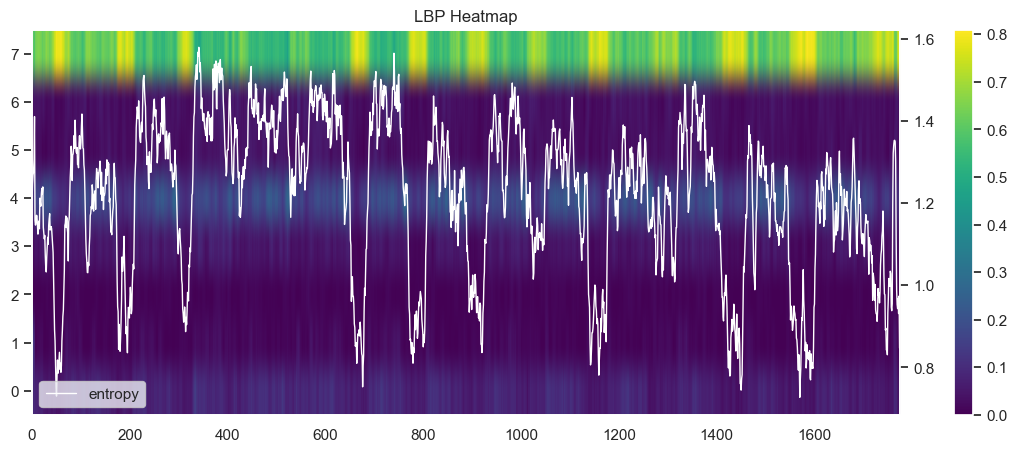

In [131]:
row = train_df[train_df["class_name"] == "Aves"].iloc[100]
fig2 = plot_lbp_heatmap(row)

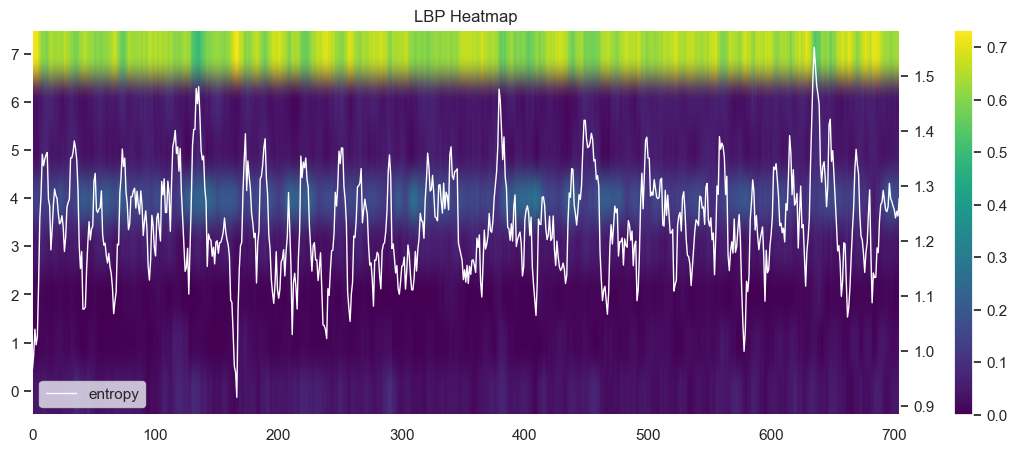

In [132]:
row = train_df[train_df["class_name"] == "Mammalia"].iloc[10]
fig2 = plot_lbp_heatmap(row)

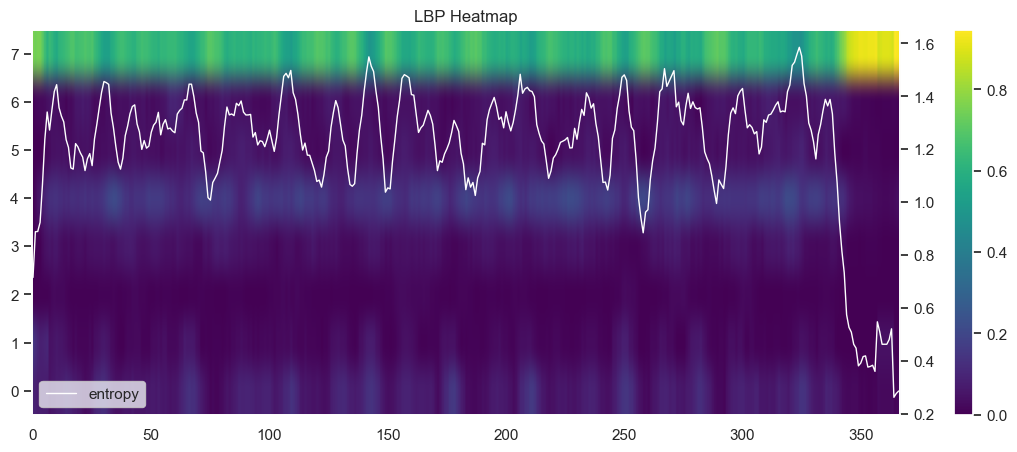

In [133]:
row = train_df[train_df["class_name"] == "Amphibia"].iloc[100]
fig2 = plot_lbp_heatmap(row)

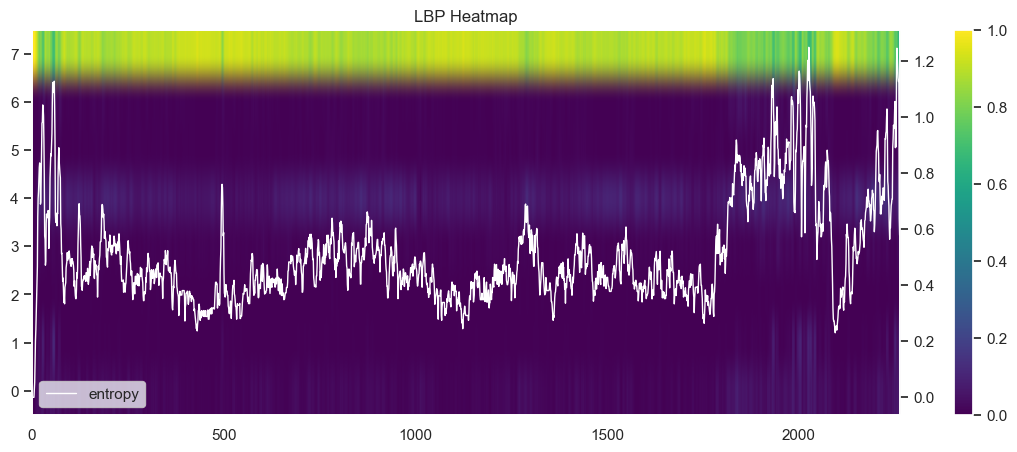

In [134]:
row = train_df[train_df["class_name"] == "Insecta"].iloc[100]
fig2 = plot_lbp_heatmap(row)

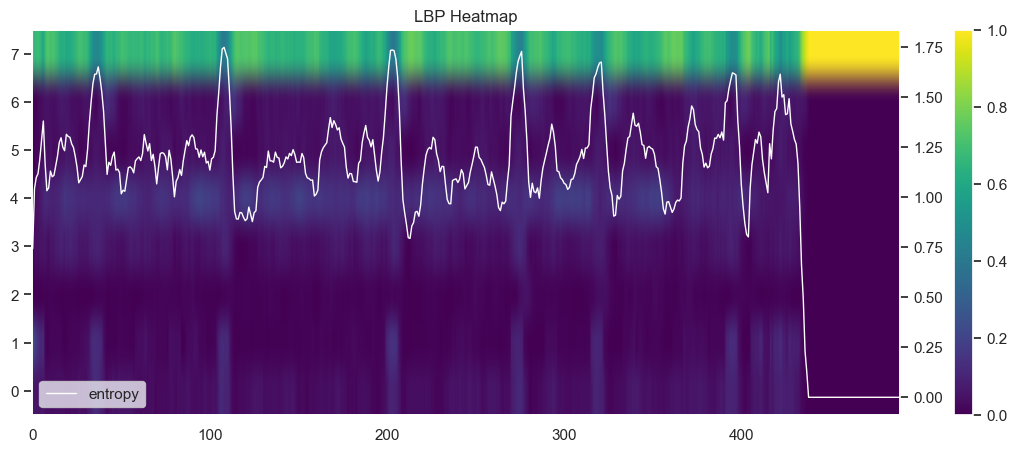

In [135]:
row = train_df[train_df["class_name"] == "Reptilia"].iloc[0]
fig2 = plot_lbp_heatmap(row)